In [1]:
# Install required package
!pip install langchain==0.3.21
!pip install langchain-openai==0.3.9
!pip install langchain-community==0.3.19
!pip install gdown
!pip install rich

  Using cached langchain-0.3.21-py3-none-any.whl.metadata (7.8 kB)
Using cached langchain-0.3.21-py3-none-any.whl (1.0 MB)
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.14
    Uninstalling langchain-0.3.14:
      Successfully uninstalled langchain-0.3.14


  Attempting uninstall: langchain-openai
    Found existing installation: langchain-openai 0.3.0
    Uninstalling langchain-openai-0.3.0:
      Successfully uninstalled langchain-openai-0.3.0


  Using cached langchain_community-0.3.19-py3-none-any.whl.metadata (2.4 kB)
Using cached langchain_community-0.3.19-py3-none-any.whl (2.5 MB)
  Attempting uninstall: langchain-community
    Found existing installation: langchain-community 0.3.14
    Uninstalling langchain-community-0.3.14:
      Successfully uninstalled langchain-community-0.3.14


## Enter API Tokens

In [7]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

Enter Open AI API Key:  ········


In [8]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY

# Load Dataset

In [9]:
import pandas as pd

df = pd.read_csv('Ecommerce_Product_List.csv')
df.head()

,Product_ID,Product_Name,Category,Price_USD,Rating,Description
0,P001,AlphaBook Pro,Laptop,1200,4.5,The AlphaBook Pro features a 15-inch Retina di...
1,P002,BetaTab S,Tablet,500,4.2,BetaTab S is a lightweight tablet with a 15-in...
2,P003,GammaPhone X,Smartphone,800,4.7,GammaPhone X comes with a 6.7-inch AMOLED disp...
3,P004,DeltaWatch 2,Smartwatch,300,4.0,"DeltaWatch 2 offers fitness tracking, heart ra..."
4,P005,EpsilonCam 300,Camera,600,4.1,EpsilonCam 300 is a mirrorless camera with a 2...


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    30 non-null     object 
 1   Product_Name  30 non-null     object 
 2   Category      30 non-null     object 
 3   Price_USD     30 non-null     int64  
 4   Rating        30 non-null     float64
 5   Description   30 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.5+ KB


In [11]:
df['Category'].unique()

array(['Laptop', 'Tablet', 'Smartphone', 'Smartwatch', 'Camera',
       'Headphones', 'Mouse', 'Keyboard', 'Monitor', 'Charger'],
      dtype=object)

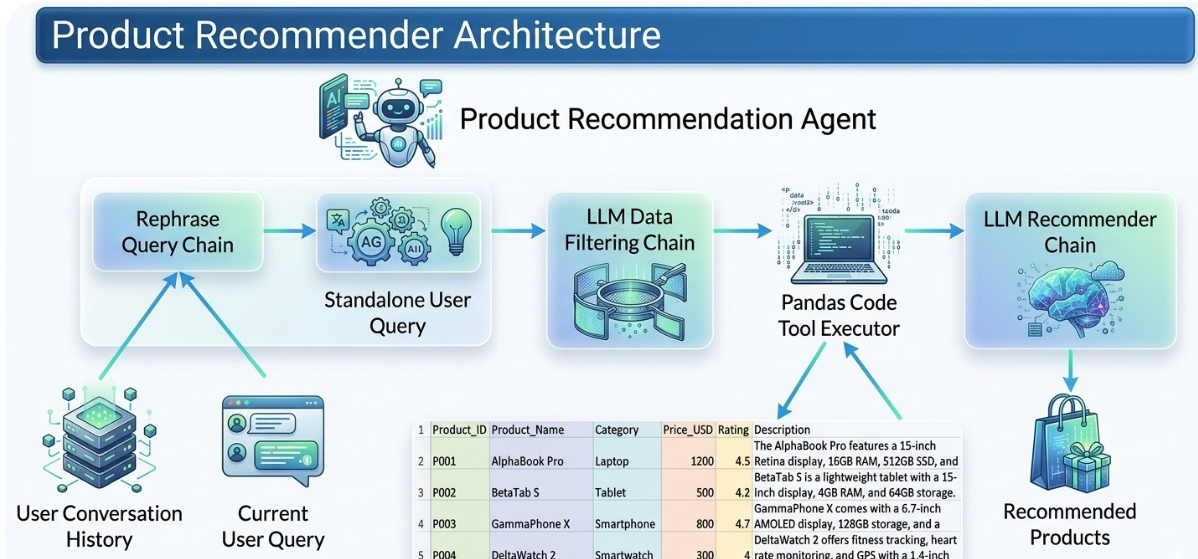

## Text to Pandas Code Tool Executor Chain

In [18]:
# Updated import path for output parsers:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import chain
from langchain.schema.runnable import RunnablePassthrough
from operator import itemgetter
# Updated import paths for prompt templates:
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from colorama import Fore
from colorama import Style


# Updated parameter name from model_name to model:
chatgpt = ChatOpenAI(model='gpt-4o-mini', temperature=0)

@chain
def pandas_code_tool_executor(query):
    print(Style.BRIGHT + Fore.CYAN + f"\n{'=' * 50}")
    print(Fore.MAGENTA + f"Query From LLM --> {query}")
    print(Style.BRIGHT + Fore.CYAN + f"{'=' * 50}\n")
    result_df = eval(query)
    if result_df.empty:
        return df.to_markdown()
    else:
        return result_df.to_markdown()

FILTER_PROMPT = """Given the following schema of a dataframe table,
            your task is to figure out the best pandas query to
            filter the dataframe based on the user query which
            will be in natural language.

            The schema is as follows:

            #   Column        Non-Null Count  Dtype
            ---  ------        --------------  -----
            0   Product_ID    30 non-null     object
            1   Product_Name  30 non-null     object
            2   Category      30 non-null     object
            3   Price_USD     30 non-null     int64
            4   Rating        30 non-null     float64
            5   Description   30 non-null     object

            Category has values: ['Laptop', 'Tablet', 'Smartphone',
                                  'Smartwatch', 'Camera',
                                  'Headphones', 'Mouse', 'Keyboard',
                                  'Monitor', 'Charger']

            Rating ranges from 1 - 5 in floats

            You will try to figure out the pandas query focusing
            only on Category, Price_USD and Rating if the user mentions
            anything about these in their natural language query.
            Do not make up column names, only use the above.
            If not the pandas query should just return the full dataframe.
            Remember the dataframe name is df.

            Just return only the pandas query and nothing else.
            Do not return the results as markdown, just return the query

            User Query: {user_query}
            Pandas Query:
        """

filter_prompt_template = ChatPromptTemplate.from_template(FILTER_PROMPT)

data_filter_chain = (
         filter_prompt_template
           |
         chatgpt
           |
         StrOutputParser()
           |
         pandas_code_tool_executor
)

product_table = data_filter_chain.invoke({"user_query": """looking for a tablet with > 10 inch display
                                                           and at least 64GB storage"""})
print(product_table)


Query From LLM --> df[df['Category'] == 'Tablet']

|    | Product_ID   | Product_Name   | Category   |   Price_USD |   Rating | Description                                                                                                                              |
|---:|:-------------|:---------------|:-----------|------------:|---------:|:-----------------------------------------------------------------------------------------------------------------------------------------|
|  1 | P002         | BetaTab S      | Tablet     |         500 |      4.2 | BetaTab S is a lightweight tablet with a 15-inch display, 4GB RAM, and 64GB storage. Perfect for entertainment and light work on the go. |
| 11 | P012         | BetaTab Lite   | Tablet     |         400 |      4.1 | BetaTab Lite is a budget-friendly 10-inch tablet with 2GB RAM and 32GB storage, perfect for casual browsing and entertainment.           |
| 21 | P022         | SpectraTab Max | Tablet     |         600 |      4.3 | Spectra

## Product Description LLM Recommender Chain

In [21]:
# Now we have relevant data based on description we going to do recommendation

RECOMMEND_PROMPT = """Act as an expert retail product advisor
                      Given the following table of products,
                      focus on the product attributes and description in the table
                      and based on the user query below do the following

                      - Recommend the most appropriate products based on the query
                      - Recommedation should have product name, price,  rating, description
                      - Also add a brief on why you recommend the product
                      - Do not make up products or recommend products not in the table
                      - If some specifications do not match focus on the ones which match and recommend
                      - If nothing matches recommend 5 random products from the table
                      - Do not generate anything else except the fields mentioned above

                    In case the user query is just a generic query or greeting
                    respond to them appropriately without recommending any products

                    Product Table:
                    {product_table}

                    User Query:
                    {user_query}

                    Recommendation:
                    """

recommend_prompt_template = ChatPromptTemplate.from_template(RECOMMEND_PROMPT)

recommend_chain = (
         recommend_prompt_template
           |
         chatgpt
           |
         StrOutputParser()
)

response = recommend_chain.invoke({"user_query": """looking for a tablet with greater than 10 inch display
                                                           and at least 64GB storage""",
                                   "product_table": product_table})
print(Fore.GREEN + f"\nLLM Recommendation: \n\n{response}")


LLM Recommendation: 

| Product_Name       | Price_USD | Rating | Description                                                                                                                              |
|--------------------|-----------|--------|------------------------------------------------------------------------------------------------------------------------------------------|
| BetaTab S          | 500       | 4.2    | BetaTab S is a lightweight tablet with a 15-inch display, 4GB RAM, and 64GB storage. Perfect for entertainment and light work on the go. |
| SpectraTab Max     | 600       | 4.3    | SpectraTab Max features a 12-inch Retina display, 6GB RAM, and 128GB storage, designed for entertainment and professional use.           |

I recommend the **BetaTab S** and **SpectraTab Max** because they both meet your criteria of having a display greater than 10 inches and at least 64GB of storage. The BetaTab S offers a larger 15-inch display, making it ideal for entertainment 

In [23]:
combined_chain = (
         {
             'user_query' : itemgetter('user_query'),
             'product_table' : data_filter_chain
         }
           |
         recommend_chain
)

In [24]:
response = combined_chain.invoke({"user_query": """looking for a cheap laptop
                                                      in the range of 500 - 1000
                                                """})
print(response)


Query From LLM --> df[(df['Category'] == 'Laptop') & (df['Price_USD'].between(500, 1000))]

| Product_Name     | Price_USD | Rating | Description                                                                                                                          |
|------------------|-----------|--------|-------------------------------------------------------------------------------------------------------------------------------------|
| AlphaBook Air    | 1000      | 4.6    | AlphaBook Air offers a sleek 13-inch Retina display, 8GB RAM, 256GB SSD, and Intel Core i5, designed for portability and efficiency. |

I recommend the AlphaBook Air because it is the only laptop in the provided table that falls within your specified price range of $500 to $1000. It offers a good balance of performance and portability with its Intel Core i5 processor, 8GB RAM, and 256GB SSD, making it suitable for various tasks while still being relatively affordable.


## Multi-user Window-based Conversation Chains with persistence

The beauty of `SQLChatMessageHistory` is that we can store separate conversation histories per user or session which is often the need for real-world chatbots which will be accessed by many users at the same time. Instead of in-memory we can store it in a SQL database which can be used to store a lot of conversations.

We use a `get_session_history` function which is expected to take in a `session_id` and return a Message History object. Everything is stored in a SQL database. This `session_id` is used to distinguish between separate conversations, and should be passed in as part of the config when calling the new chain

We also use a `memory_buffer_window` function to only use the top-K last historical conversations before sending it to the LLM, basically our own implementation of `ConversationBufferWindowMemory`

## SQLChatMessageHistory
 - Stores chat messages in a database (persistent memory)
## RunnableWithMessageHistory
- Automatically loads and updates chat history while running a chain

In [32]:
from langchain_community.chat_message_histories import SQLChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder

# used to retrieve conversation history from database
# based on a specific user or session ID
def get_session_history_db(session_id):
    return SQLChatMessageHistory(session_id, "sqlite:///memory.db")


SYS_PROMPT = """You are a retail product expert.
                Carefully analyze the following conversation history
                and the current user query.
                Refer to the history and rephrase the current user query
                into a standalone query which can be used without the history
                for making search queries.
                Rephrase only if needed.
                Just return the query and do not answer it.
            """

# prompt to load in history and current input from the user
prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system", SYS_PROMPT),
        MessagesPlaceholder(variable_name="history"),
        ("human", """Current User Query:
                     {human_input}
                  """),
    ]
)

# create a memory buffer window function to return the last K conversations
def memory_buffer_window(messages, k=10): # 10 here means retrieve only last 2*10 user-AI conversations
    return messages[-(2*k):]

# create a basic LLM Chain which only sends the last K conversations per user
rephrase_query_chain = (
    RunnablePassthrough.assign(history=lambda x: memory_buffer_window(x["history"]))
      |
    prompt_template
      |
    chatgpt
      |
    StrOutputParser()
)

## Combining All Chains Together

In [33]:
combined_chain = (
         {
             'human_input' : itemgetter('human_input'),
             'history' : itemgetter('history')
         }
           |
        {
            'user_query': rephrase_query_chain
        }
           |
        RunnablePassthrough.assign(product_table=data_filter_chain)
            |
        recommend_chain
)

## Test Product Recommender Agent¶

In [34]:
from rich.console import Console
from rich.markdown import Markdown

# create a conversation chain which can load memory based on specific user or session id
# RunnableWithMessageHistory - used to manage
conv_chain = RunnableWithMessageHistory(
    combined_chain,
    get_session_history_db,
    input_messages_key="human_input",
    history_messages_key="history",
)

# create a utility function to take in current user input prompt and their session ID
# streams result live back to the user from the LLM
def chat_with_llm(prompt: str, session_id: str):
    response = conv_chain.invoke({"human_input": prompt},
                                 {'configurable': { 'session_id': session_id}})
    console = Console()
    console.print(Markdown(response))


In [35]:
user_id = 'AI001'
prompt = "looking for a tablet"
chat_with_llm(prompt, user_id)

C:\Users\sathish.anantharaj\AppData\Local\anaconda3\Lib\site-packages\langchain_core\runnables\history.py:596: LangChainDeprecationWarning: `connection_string` was deprecated in LangChain 0.2.2 and will be removed in 1.0. Use connection instead.
  message_history = self.get_session_history(



Query From LLM --> df[df['Category'] == 'Tablet']



 Product_Name     Price_USD   Rating   Description                                                                
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  BetaTab S        500         4.2      BetaTab S is a lightweight tablet with a 15-inch display, 4GB RAM, and     
                                        64GB storage. Perfect for entertainment and light work on the go.          
  BetaTab Lite     400         4.1      BetaTab Lite is a budget-friendly 10-inch tablet with 2GB RAM and 32GB     
                                        storage, perfect for casual browsing and entertainment.                    
  SpectraTab Max   600         4.3      SpectraTab Max features a 12-inch Retina display, 6GB RAM, and 128GB       
                                        storage, designed for entertainment and professional use.                  
                                                                                                                   

I recommend these tablets because they cater to a variety of needs and budgets. The BetaTab S is great for those   
who want a larger display and more power for multitasking. The BetaTab Lite is ideal for casual users looking for  
an affordable option, while the SpectraTab Max offers high performance and a premium display for both entertainment
and professional tasks.